In [3]:
import pandas as pd
df = pd.read_csv("payer_unsupervised_anomaly_data.csv")
df.head()

,ClaimID,PatientID,ProviderID,ClaimDate,ServiceDate,DOB,DiagnosisCode,ProcedureCode,ClaimAmount,PatientGender,ZIP,State,ProviderSpecialty,ProviderLocation,ClaimStatus,ClaimType
0,f645d790-b365-49a7-92c4-97c7ade14442,58a2eb39-fc48-4d38-b228-a09d09591df2,2c799ea8-0106-4bb6-8d56-d888d66bb102,2024-05-02,2024-03-12,1980-02-27,Vu487,tN660,1821.56,M,99874,MA,Orthopedics,Garciaburgh,Denied,Emergency
1,7d4fcf46-8161-46f5-8620-c8536c609a52,5270bfcc-cb48-461a-ba63-12c905a0e224,b330be36-f041-4bbf-98d9-1050bf5c309c,2023-05-26,2025-08-13,2010-05-15,vQ181,mL117,6633.84,F,78549,ID,NaN,East John,Denied,Inpatient
2,NaN,a161cfa6-d2e1-4b31-84f5-18855a5eb868,a69c2947-2198-46d1-bb26-549db39d62e0,NaN,2023-12-12,NaN,Nq668,Ug993,9601.93,M,52463,SD,Neurology,Johnsonland,Denied,Routine
3,8bd96d46-53d2-41fb-907a-7d33c62992a4,daa96234-e32e-4f73-bd9b-5421acd80896,96b2be96-04ab-4c57-ac75-86c0ae9b5650,2023-11-12,2025-01-31,1957-09-13,Dy345,Sb138,3865.97,F,67357,NaN,Cardiology,Lake Lauraton,Denied,Outpatient
4,1b34cdfe-81b3-4959-99cb-ca7bf6e57f63,0f91c64f-bdcf-4f85-9aca-873be92559d8,7084e6b4-a3eb-478d-a575-04031c75bd7c,2023-05-08,2025-03-09,1960-01-08,Zv703,Zl922,4134.68,M,82788,OK,Neurology,North Chase,Denied,Inpatient


In [4]:
df.head()

,ClaimID,PatientID,ProviderID,ClaimDate,ServiceDate,DOB,DiagnosisCode,ProcedureCode,ClaimAmount,PatientGender,ZIP,State,ProviderSpecialty,ProviderLocation,ClaimStatus,ClaimType
0,f645d790-b365-49a7-92c4-97c7ade14442,58a2eb39-fc48-4d38-b228-a09d09591df2,2c799ea8-0106-4bb6-8d56-d888d66bb102,2024-05-02,2024-03-12,1980-02-27,Vu487,tN660,1821.56,M,99874,MA,Orthopedics,Garciaburgh,Denied,Emergency
1,7d4fcf46-8161-46f5-8620-c8536c609a52,5270bfcc-cb48-461a-ba63-12c905a0e224,b330be36-f041-4bbf-98d9-1050bf5c309c,2023-05-26,2025-08-13,2010-05-15,vQ181,mL117,6633.84,F,78549,ID,NaN,East John,Denied,Inpatient
2,NaN,a161cfa6-d2e1-4b31-84f5-18855a5eb868,a69c2947-2198-46d1-bb26-549db39d62e0,NaN,2023-12-12,NaN,Nq668,Ug993,9601.93,M,52463,SD,Neurology,Johnsonland,Denied,Routine
3,8bd96d46-53d2-41fb-907a-7d33c62992a4,daa96234-e32e-4f73-bd9b-5421acd80896,96b2be96-04ab-4c57-ac75-86c0ae9b5650,2023-11-12,2025-01-31,1957-09-13,Dy345,Sb138,3865.97,F,67357,NaN,Cardiology,Lake Lauraton,Denied,Outpatient
4,1b34cdfe-81b3-4959-99cb-ca7bf6e57f63,0f91c64f-bdcf-4f85-9aca-873be92559d8,7084e6b4-a3eb-478d-a575-04031c75bd7c,2023-05-08,2025-03-09,1960-01-08,Zv703,Zl922,4134.68,M,82788,OK,Neurology,North Chase,Denied,Inpatient


In [ ]:
# percentage of missing values per column
df.isna().mean().sort_values(ascending=False).round(3)

ClaimID              0.050
PatientID            0.050
ProviderID           0.050
DiagnosisCode        0.050
ProviderSpecialty    0.050
State                0.050
ZIP                  0.050
PatientGender        0.050
ClaimStatus          0.050
ProviderLocation     0.050
ClaimType            0.050
ClaimDate            0.050
DOB                  0.050
ServiceDate          0.049
ProcedureCode        0.049
ClaimAmount          0.048
dtype: float64

In [ ]:
# number of duplicate ClaimID entries
df.duplicated(subset=["ClaimID"]).sum()

np.int64(237)

In [7]:
df["ClaimAmount"].describe()

count      2943
unique     2859
top       $5000
freq          5
Name: ClaimAmount, dtype: object

count    2.931000e+03
mean     3.278270e+04
std      2.964435e+05
min     -1.940120e+03
25%      2.490840e+03
50%      5.014970e+03
75%      7.488050e+03
max      4.754651e+06
Name: ClaimAmount, dtype: float64


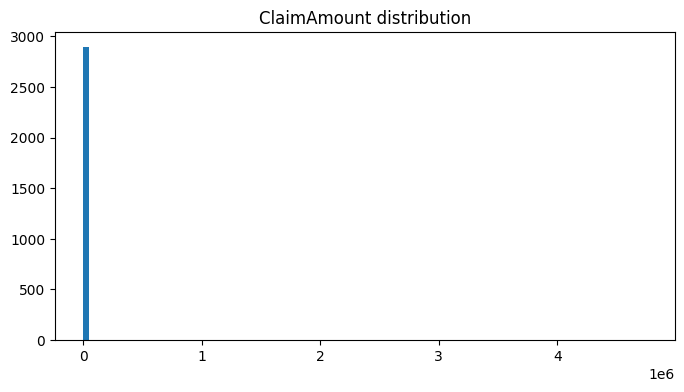

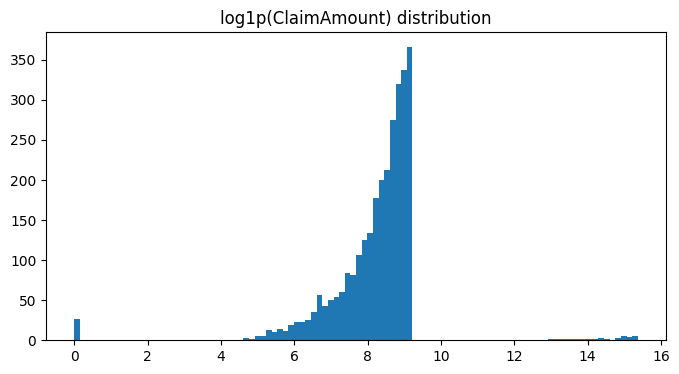

In [8]:
# Cell: quick numeric summary & visual checks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("payer_unsupervised_anomaly_data.csv")
# convert ClaimAmount to numeric (coerce errors -> NaN)
df['ClaimAmount'] = pd.to_numeric(df['ClaimAmount'], errors='coerce')

# basic stats
print(df['ClaimAmount'].describe())

# histogram (log scale helps see extremes)
plt.figure(figsize=(8,4))
plt.hist(df['ClaimAmount'].dropna(), bins=100)
plt.title("ClaimAmount distribution")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(np.log1p(df['ClaimAmount'].dropna().clip(lower=0)), bins=100)
plt.title("log1p(ClaimAmount) distribution")
plt.show()


In [9]:
# Cell: add rule-based flags
import scipy.stats as stats

ser = pd.to_numeric(df['ClaimAmount'], errors='coerce')

# IQR method
Q1 = ser.quantile(0.25)
Q3 = ser.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['outlier_iqr'] = ((ser < lower) | (ser > upper)).astype(int)

# Z-score method (robust: use median & MAD or standard z)
z = (ser - ser.mean()) / (ser.std(ddof=0) + 1e-9)
df['outlier_zscore'] = (z.abs() > 3).astype(int)

# Business threshold (example): anything > 100k or < 0 is suspect
df['outlier_business'] = ((ser > 100000) | (ser < 0)).astype(int)

# Combined flag
df['outlier_rule_flag'] = ((df['outlier_iqr'] + df['outlier_zscore'] + df['outlier_business']) > 0).astype(int)

# Quick counts
print("IQR:", df['outlier_iqr'].sum(), "Z>3:", df['outlier_zscore'].sum(), "Business:", df['outlier_business'].sum())
print("Combined flagged:", df['outlier_rule_flag'].sum())


IQR: 34 Z>3: 28 Business: 61
Combined flagged: 61


In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("payer_unsupervised_anomaly_data.csv")

# =============== NORMALIZE DATATYPES ===============

# Convert date-like columns to datetime
date_cols = ["ClaimDate", "ServiceDate", "DOB"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")  # invalid formats -> NaT (keep anomalies)

# Convert claim amount to numeric (bad formats -> NaN)
df["ClaimAmount"] = pd.to_numeric(df["ClaimAmount"], errors="coerce")

# =============== STANDARDIZE STRING FIELDS ===============

str_cols = [
    "DiagnosisCode", "ProcedureCode",
    "PatientGender", "ZIP", "State",
    "ProviderSpecialty", "ProviderLocation",
    "ClaimStatus", "ClaimType"
]

for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.upper().replace({"NAN": np.nan})

# ensure ZIP stays string
df["ZIP"] = df["ZIP"].astype(str).str.replace(" ", "").replace(".0","", regex=False)

# Clean ID columns
df["ClaimID"] = df["ClaimID"].astype(str).str.strip()
df["PatientID"] = df["PatientID"].astype(str).str.strip()
df["ProviderID"] = df["ProviderID"].astype(str).str.strip()

print("Normalization complete!")
df.head()


Normalization complete!


,ClaimID,PatientID,ProviderID,ClaimDate,ServiceDate,DOB,DiagnosisCode,ProcedureCode,ClaimAmount,PatientGender,ZIP,State,ProviderSpecialty,ProviderLocation,ClaimStatus,ClaimType
0,f645d790-b365-49a7-92c4-97c7ade14442,58a2eb39-fc48-4d38-b228-a09d09591df2,2c799ea8-0106-4bb6-8d56-d888d66bb102,2024-05-02,2024-03-12,1980-02-27,VU487,TN660,1821.56,M,99874,MA,ORTHOPEDICS,GARCIABURGH,DENIED,EMERGENCY
1,7d4fcf46-8161-46f5-8620-c8536c609a52,5270bfcc-cb48-461a-ba63-12c905a0e224,b330be36-f041-4bbf-98d9-1050bf5c309c,2023-05-26,2025-08-13,2010-05-15,VQ181,ML117,6633.84,F,78549,ID,NaN,EAST JOHN,DENIED,INPATIENT
2,nan,a161cfa6-d2e1-4b31-84f5-18855a5eb868,a69c2947-2198-46d1-bb26-549db39d62e0,NaT,2023-12-12,NaT,NQ668,UG993,9601.93,M,52463,SD,NEUROLOGY,JOHNSONLAND,DENIED,ROUTINE
3,8bd96d46-53d2-41fb-907a-7d33c62992a4,daa96234-e32e-4f73-bd9b-5421acd80896,96b2be96-04ab-4c57-ac75-86c0ae9b5650,2023-11-12,2025-01-31,1957-09-13,DY345,SB138,3865.97,F,67357,NaN,CARDIOLOGY,LAKE LAURATON,DENIED,OUTPATIENT
4,1b34cdfe-81b3-4959-99cb-ca7bf6e57f63,0f91c64f-bdcf-4f85-9aca-873be92559d8,7084e6b4-a3eb-478d-a575-04031c75bd7c,2023-05-08,2025-03-09,1960-01-08,ZV703,ZL922,4134.68,M,82788,OK,NEUROLOGY,NORTH CHASE,DENIED,INPATIENT


In [ ]:
# 1) days between service and claim (can be positive or NaN)
df["days_between_service_and_claim"] = abs(df["ClaimDate"] - df["ServiceDate"]).dt.days

# 2) age from dob (NaN if DOB or ClaimDate invalid). Keep raw float (years)
df["age_from_dob"] = ((df["ClaimDate"] - df["DOB"]).dt.days / 365.25).round(2)

# 3) provider claim frequency (how many claims that provider has) — integer
df["provider_claim_count"] = df.groupby("ProviderID")["ClaimID"].transform("count")

# 4) claims per patient (rare patients may be anomalies)
df["claims_per_patient"] = df.groupby("PatientID")["ClaimID"].transform("count")

# quick inspect
print(df[["days_between_service_and_claim","age_from_dob","provider_claim_count"]].describe().T)


                                 count        mean         std  min       25%  \
days_between_service_and_claim  2763.0  513.033297  290.484498  0.0  289.5000   
age_from_dob                    2778.0   47.355504   23.987691 -1.0   26.1025   
provider_claim_count            3090.0    8.679612   33.288116  1.0    1.0000   
claims_per_patient              3090.0    8.678317   33.288395  1.0    1.0000   

                                    50%     75%      max  
days_between_service_and_claim  502.000  722.50  1216.00  
age_from_dob                     48.065   68.38    89.18  
provider_claim_count              1.000    1.00   154.00  
claims_per_patient                1.000    1.00   154.00  


In [13]:
#Data Quality Checks

import pandas as pd
import numpy as np
import json
import os
import re
from datetime import datetime

# ---------- CONFIG ----------
CANDIDATES = ["claims_cleaned_with_flags.csv", "payer_unsupervised_anomaly_data.csv"]
INFILE = next((f for f in CANDIDATES if os.path.exists(f)), CANDIDATES[-1])
OUT_FLAGS = "dq_flags.csv"
OUT_SUMMARY = "dq_summary.json"
TOP_K = 20
# business thresholds
BUSINESS_EXTREME_AMOUNT = 100_000.0  # USD considered extreme for claims in many payer contexts

# US state abbreviations (simple authoritative list)
US_STATES = {
 "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA",
 "ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK",
 "OR","PA","RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
}
# columns considered important for missing_count
KEY_COLS = ["ClaimID","PatientID","ProviderID","ClaimAmount","ClaimDate","DiagnosisCode","ProcedureCode","ZIP","State"]

# ---------- Helpers ----------
def is_valid_code(val):
    # allow alnum and dot, length up to 12; uppercase expected
    if pd.isna(val): 
        return False
    v = str(val).strip().upper()
    return bool(re.match(r'^[A-Z0-9\.]{1,12}$', v))

def safe_parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c + "_PARSED"] = pd.to_datetime(df[c], errors="coerce")
        else:
            df[c + "_PARSED"] = pd.NaT
    return df

# ---------- Load ----------
print("Loading:", INFILE)
df_raw = pd.read_csv(INFILE, dtype=str)  # load as strings to preserve raw anomalies
n0 = len(df_raw)
print("Rows loaded:", n0)

# Work on a copy (do not mutate original file)
df = df_raw.copy()

# ---------- Minimal normalization for checks ----------
# we parse numeric and dates but DO NOT modify original columns
# Parse dates (keep NaT as indicator)
for c in ["ClaimDate","ServiceDate","DOB"]:
    if c in df.columns:
        df[c + "_PARSED"] = pd.to_datetime(df[c], errors="coerce")
    else:
        df[c + "_PARSED"] = pd.NaT

# Parse ClaimAmount numeric
if "ClaimAmount" in df.columns:
    # preserve original string in claim_amount_raw if present
    df["claim_amount_raw_str"] = df["ClaimAmount"].astype(str)
    df["ClaimAmount_NUM"] = pd.to_numeric(df["ClaimAmount"], errors="coerce")
else:
    df["ClaimAmount_NUM"] = np.nan
    df["claim_amount_raw_str"] = np.nan

# ---------- DQ FLAGS ----------

# 1) Missingness
df["missing_count"] = df[KEY_COLS].isna().sum(axis=1)

# also missing key flag
df["missing_key"] = df[["ClaimID","PatientID","ProviderID","ClaimAmount","ClaimDate"]].isna().any(axis=1).astype(int)

# 2) Exact duplicate full-row
df["dup_full_row"] = df.duplicated(keep=False).astype(int)

# 3) Duplicate ClaimID
if "ClaimID" in df.columns:
    df["dup_claimid_flag"] = df["ClaimID"].duplicated(keep=False).astype(int)
else:
    df["dup_claimid_flag"] = 0

# 4) Parse/format issues: dates
df["bad_claimdate"] = df["ClaimDate_PARSED"].isna().astype(int) if "ClaimDate_PARSED" in df.columns else 1
df["bad_servicedate"] = df["ServiceDate_PARSED"].isna().astype(int) if "ServiceDate_PARSED" in df.columns else 1
df["bad_dob"] = df["DOB_PARSED"].isna().astype(int) if "DOB_PARSED" in df.columns else 1

# 5) ZIP check: 5-digit numeric
def zip_bad(x):
    try:
        s = str(x).strip()
        return not (s.isdigit() and len(s)==5)
    except:
        return True
if "ZIP" in df.columns:
    df["bad_zip"] = df["ZIP"].apply(zip_bad).astype(int)
else:
    df["bad_zip"] = 1

# 6) State check: must be 2-letter US state
if "State" in df.columns:
    df["bad_state"] = df["State"].apply(lambda v: 0 if (isinstance(v,str) and v.strip().upper() in US_STATES) else 1)
else:
    df["bad_state"] = 1

# 7) ClaimAmount format issues
df["bad_amount_format"] = df["ClaimAmount_NUM"].isna().astype(int)

# 8) Diagnosis/Procedure code formats
df["bad_diag_code"] = df["DiagnosisCode"].apply(lambda v: 0 if is_valid_code(v) else 1) if "DiagnosisCode" in df.columns else 1
df["bad_proc_code"] = df["ProcedureCode"].apply(lambda v: 0 if is_valid_code(v) else 1) if "ProcedureCode" in df.columns else 1

# 9) Logical inconsistencies
# dob_after_claim
df["dob_after_claim"] = 0
if "DOB_PARSED" in df.columns and "ClaimDate_PARSED" in df.columns:
    mask = df["DOB_PARSED"].notna() & df["ClaimDate_PARSED"].notna() & (df["DOB_PARSED"] > df["ClaimDate_PARSED"])
    df.loc[mask, "dob_after_claim"] = 1

# service_after_claim
df["service_after_claim"] = 0
if "ServiceDate_PARSED" in df.columns and "ClaimDate_PARSED" in df.columns:
    mask2 = df["ServiceDate_PARSED"].notna() & df["ClaimDate_PARSED"].notna() & (df["ServiceDate_PARSED"] > df["ClaimDate_PARSED"])
    df.loc[mask2, "service_after_claim"] = 1

# 10) Negative or zero claim amounts
df["negative_amount"] = ((df["ClaimAmount_NUM"] < 0).fillna(False)).astype(int)
df["zero_amount"] = ((df["ClaimAmount_NUM"] == 0).fillna(False)).astype(int)

# ---------- Outlier detection for ClaimAmount ----------
amt = df["ClaimAmount_NUM"].dropna().astype(float)
outlier_iqr = pd.Series(False, index=df.index)
outlier_robust = pd.Series(False, index=df.index)

if len(amt) > 0:
    Q1 = amt.quantile(0.25)
    Q3 = amt.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    outlier_iqr = ((df["ClaimAmount_NUM"] < lower_iqr) | (df["ClaimAmount_NUM"] > upper_iqr))
    # robust zscore using MAD
    median = amt.median()
    mad = (np.abs(amt - median)).median()
    eps = 1e-9
    robust_z = (df["ClaimAmount_NUM"] - median) / (1.4826 * mad + eps)
    outlier_robust = robust_z.abs() > 3.5
else:
    outlier_iqr[:] = False
    outlier_robust[:] = False

df["outlier_iqr_claimamount"] = outlier_iqr.fillna(False).astype(int)
df["outlier_robust_z_claimamount"] = outlier_robust.fillna(False).astype(int)
df["extreme_amount"] = ((df["ClaimAmount_NUM"] > BUSINESS_EXTREME_AMOUNT).fillna(False)).astype(int)

# 11) Combined simple outlier flag (any of amount flags)
df["amount_suspect_flag"] = ((df["outlier_iqr_claimamount"] == 1) | (df["outlier_robust_z_claimamount"] == 1) | (df["negative_amount"]==1) | (df["extreme_amount"]==1)).astype(int)

# ---------- DQ SCORE ----------
# list of boolean flag columns included in score
flag_cols = [
    "missing_key","dup_full_row","dup_claimid_flag",
    "bad_claimdate","bad_servicedate","bad_dob","bad_zip","bad_state","bad_amount_format",
    "bad_diag_code","bad_proc_code",
    "dob_after_claim","service_after_claim",
    "negative_amount","zero_amount","amount_suspect_flag"
]

# Ensure existing
flag_cols = [c for c in flag_cols if c in df.columns]

df["dq_flag_count"] = df[flag_cols].sum(axis=1)
max_flags_possible = len(flag_cols) if len(flag_cols)>0 else 1
df["dq_score"] = df["dq_flag_count"] / float(max_flags_possible)
# severity buckets
def sev(score):
    if score >= 0.5:
        return "HIGH"
    if score >= 0.2:
        return "MEDIUM"
    if score > 0:
        return "LOW"
    return "CLEAN"
df["dq_severity"] = df["dq_score"].apply(sev)

# ---------- Prepare outputs ----------
# Select a compact set to write: original raw cols + parsed cols + flags + dq metrics
out_cols = list(df_raw.columns)  # original raw columns preserved in df
# add parsed columns if exist
parsed_cols = [c for c in df.columns if c.endswith("_PARSED")]
# add flags & dq metrics
meta_cols = flag_cols + ["dq_flag_count","dq_score","dq_severity"]
write_cols = out_cols + parsed_cols + meta_cols

# make sure columns unique and exist
write_cols = [c for c in write_cols if c in df.columns]
dq_out = df[write_cols].copy()

dq_out.to_csv(OUT_FLAGS, index=False)

# ---------- Summary JSON ----------
summary = {
    "rows": int(len(df)),
    "loaded_from": INFILE,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "flags_counts": {c: int(df[c].sum()) for c in flag_cols},
    "dq_score_stats": {
        "mean": float(df["dq_score"].mean()),
        "median": float(df["dq_score"].median()),
        "pct_zero_flags": float((df["dq_score"]==0).mean())
    },
    "duplicate_claimid_count": int(df["dup_claimid_flag"].sum()) if "dup_claimid_flag" in df.columns else 0
}
with open(OUT_SUMMARY, "w") as f:
    json.dump(summary, f, indent=2)

# ---------- Print human summary ----------
print("\nDQ checks complete.")
print("Wrote:", OUT_FLAGS, "and", OUT_SUMMARY)
print("\nTop flag counts (desc):")
for k,v in sorted(summary["flags_counts"].items(), key=lambda x: -x[1])[:15]:
    print(f"  {k:30s} {v}")

print("\nDQ score (mean, median, pct clean):",
      round(summary["dq_score_stats"]["mean"],4),
      round(summary["dq_score_stats"]["median"],4),
      f"{round(summary['dq_score_stats']['pct_zero_flags']*100,2)}% clean rows")

# show top-K highest DQ score rows (brief)
print(f"\nTop {TOP_K} rows by dq_score:")
display_cols = (out_cols[:8] if len(out_cols)>=8 else out_cols) + ["dq_score","dq_severity"] + flag_cols[:6]
print(df[display_cols].sort_values("dq_score", ascending=False).head(TOP_K).to_string(index=False))


Loading: payer_unsupervised_anomaly_data.csv
Rows loaded: 3090

DQ checks complete.
Wrote: dq_flags.csv and dq_summary.json

Top flag counts (desc):
  service_after_claim            2639
  missing_key                    688
  bad_state                      581
  dup_claimid_flag               322
  bad_servicedate                172
  bad_zip                        168
  bad_claimdate                  163
  bad_dob                        161
  bad_amount_format              159
  bad_proc_code                  155
  bad_diag_code                  154
  amount_suspect_flag            61
  dup_full_row                   32
  negative_amount                27
  dob_after_claim                22

DQ score (mean, median, pct clean): 0.1113 0.125 1.88% clean rows

Top 20 rows by dq_score:
                             ClaimID                            PatientID                           ProviderID  ClaimDate ServiceDate        DOB DiagnosisCode ProcedureCode  dq_score dq_severity  missing_ke